# ShiftGuard AI: Decision Fatigue Score Prediction (Regression)

**Report-style notebook** — structured like comparative algorithm papers: dataset description, exploratory analysis, methodology, **results tables**, and **figures** for export to PDF.

**Target:** `Decision_Fatigue_Score` (0–100)  
**Task:** Supervised regression from behavioral features.

---
*Edit the markdown cells below with your team names and abstract for the final submission.*


## Abstract

Sustained decision-making under time pressure is linked to cognitive fatigue and errors. This study trains and compares supervised **regression** models to estimate a composite **decision fatigue score** from observable inputs (sleep, workload, stress, etc.). Models are evaluated on a held-out test set with standard error metrics and residual diagnostics. The workflow is suitable for a decision-support prototype in scheduling or workload management.

**Index terms:** Decision fatigue, supervised learning, regression, scikit-learn.


## 1. Introduction

Fatigue affects judgment, consistency, and error rates. Models that estimate fatigue-related risk from **measurable** variables can support breaks, staffing, or task pacing. This notebook documents **data loading**, **EDA**, **multiple regressors**, and **evaluation** — the material typically required for an AI / ML project report.


## 2. Materials: Dataset and Setup

- **Data file:** `human_decision_fatigue_dataset.csv` (project root).
- **Rows:** ~25k after duplicate removal.
- **Software:** Python, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`.

**Preprocessing (inside each model pipeline):**
- Drop duplicate rows.
- One-hot encode `Time_of_Day`.
- Standardize numeric features.

**Split:** 80% train / 20% test, fixed seed for reproducibility.

**Metrics:** MAE, RMSE, R² on the test set; optional 5-fold CV on training data.


In [2]:
# Imports and display settings
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE = Path.cwd()
DATA_PATH = BASE / "human_decision_fatigue_dataset.csv"
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Place human_decision_fatigue_dataset.csv in: {BASE}")

# Style (fallback if seaborn v0_8 theme missing)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
FIG_DPI = 120
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 10


In [3]:
NUMERIC_FEATURES = [
    "Hours_Awake",
    "Decisions_Made",
    "Task_Switches",
    "Avg_Decision_Time_sec",
    "Sleep_Hours_Last_Night",
    "Caffeine_Intake_Cups",
    "Stress_Level_1_10",
    "Error_Rate",
    "Cognitive_Load_Score",
]
CATEGORICAL_FEATURES = ["Time_of_Day"]
TARGET = "Decision_Fatigue_Score"
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

df = pd.read_csv(DATA_PATH)
n_before = len(df)
df = df.drop_duplicates()
print(f"Rows: {len(df)} (dropped {n_before - len(df)} duplicates)")
df.head()


Rows: 24999 (dropped 1 duplicates)


,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score
0,7,28,7,2.30,5.8,Evening,0,2.4,0.000,2.6,15.6
1,15,77,22,3.65,4.5,Afternoon,3,1.9,0.143,4.5,97.3
2,11,57,23,3.67,6.8,Night,2,2.1,0.000,4.1,55.4
3,8,39,10,2.39,5.3,Afternoon,1,1.0,0.000,2.3,29.7
4,7,46,16,3.05,8.2,Night,1,2.8,0.000,3.9,19.1


## 3. Exploratory Data Analysis (EDA)


In [4]:
# Table I — Variable overview
desc = df[FEATURES + [TARGET]].describe(include="all").T
print("Table I. Summary statistics.")
display(desc)


Table I. Summary statistics.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Awake,24999.0,NaN,NaN,NaN,9.088604,4.927926,1.0,5.0,9.0,13.0,17.0
Decisions_Made,24999.0,NaN,NaN,NaN,45.434697,25.610819,0.0,23.0,45.0,67.0,117.0
Task_Switches,24999.0,NaN,NaN,NaN,13.624025,8.52133,0.0,7.0,13.0,20.0,48.0
Avg_Decision_Time_sec,24999.0,NaN,NaN,NaN,2.918406,0.942616,0.5,2.27,2.91,3.55,6.8
Sleep_Hours_Last_Night,24999.0,NaN,NaN,NaN,6.085927,1.114599,2.0,5.3,6.1,6.9,9.0
Caffeine_Intake_Cups,24999.0,NaN,NaN,NaN,1.897276,1.430501,0.0,1.0,2.0,3.0,6.0
Stress_Level_1_10,24999.0,NaN,NaN,NaN,2.202784,1.329873,1.0,1.0,1.8,3.1,8.7
Error_Rate,24999.0,NaN,NaN,NaN,0.031879,0.057458,0.0,0.0,0.0,0.045,0.359
Cognitive_Load_Score,24999.0,NaN,NaN,NaN,3.365887,1.729051,0.6,1.9,3.2,4.6,9.7
Time_of_Day,24999,4,Afternoon,8826,NaN,NaN,NaN,NaN,NaN,NaN,NaN


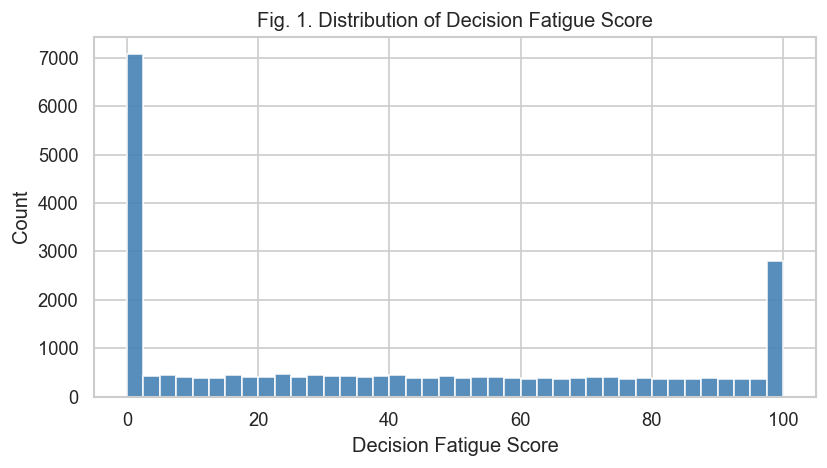

Mean: 40.58  Std: 36.70


In [5]:
# Fig. 1 — Target distribution
fig, ax = plt.subplots(figsize=(7, 4), dpi=FIG_DPI)
ax.hist(df[TARGET], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
ax.set_xlabel("Decision Fatigue Score")
ax.set_ylabel("Count")
ax.set_title("Fig. 1. Distribution of Decision Fatigue Score")
plt.tight_layout()
plt.show()
print(f"Mean: {df[TARGET].mean():.2f}  Std: {df[TARGET].std():.2f}")


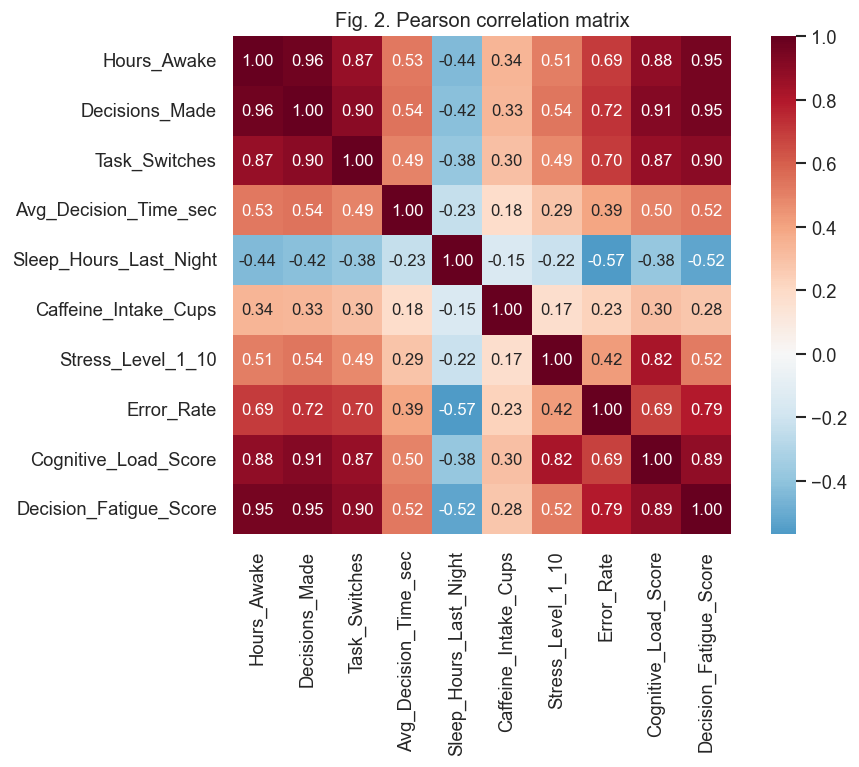

In [6]:
# Fig. 2 — Correlation heatmap (numeric + target)
num_cols = NUMERIC_FEATURES + [TARGET]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=FIG_DPI)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Fig. 2. Pearson correlation matrix")
plt.tight_layout()
plt.show()


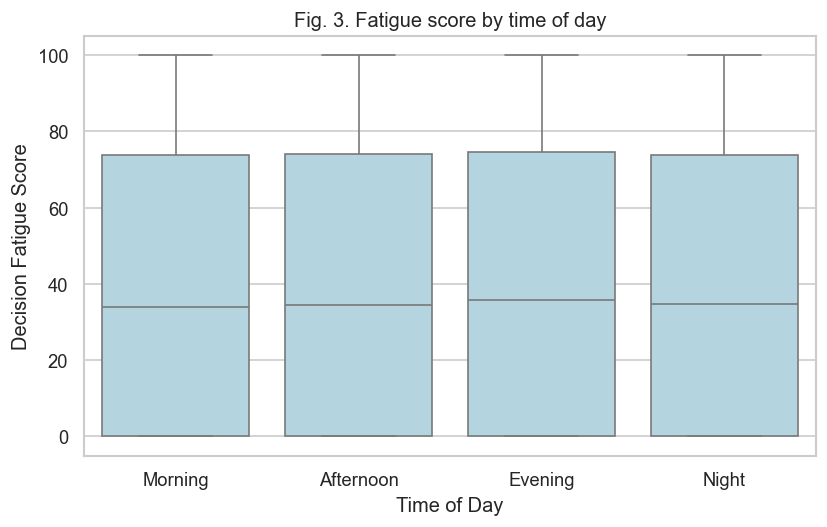

In [8]:
# Fig. 3 — Score by time of day
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=FIG_DPI)
order = ["Morning", "Afternoon", "Evening", "Night"]
sns.boxplot(data=df, x="Time_of_Day", y=TARGET, order=order, ax=ax, color="lightblue")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Decision Fatigue Score")
ax.set_title("Fig. 3. Fatigue score by time of day")
plt.tight_layout()
plt.show()


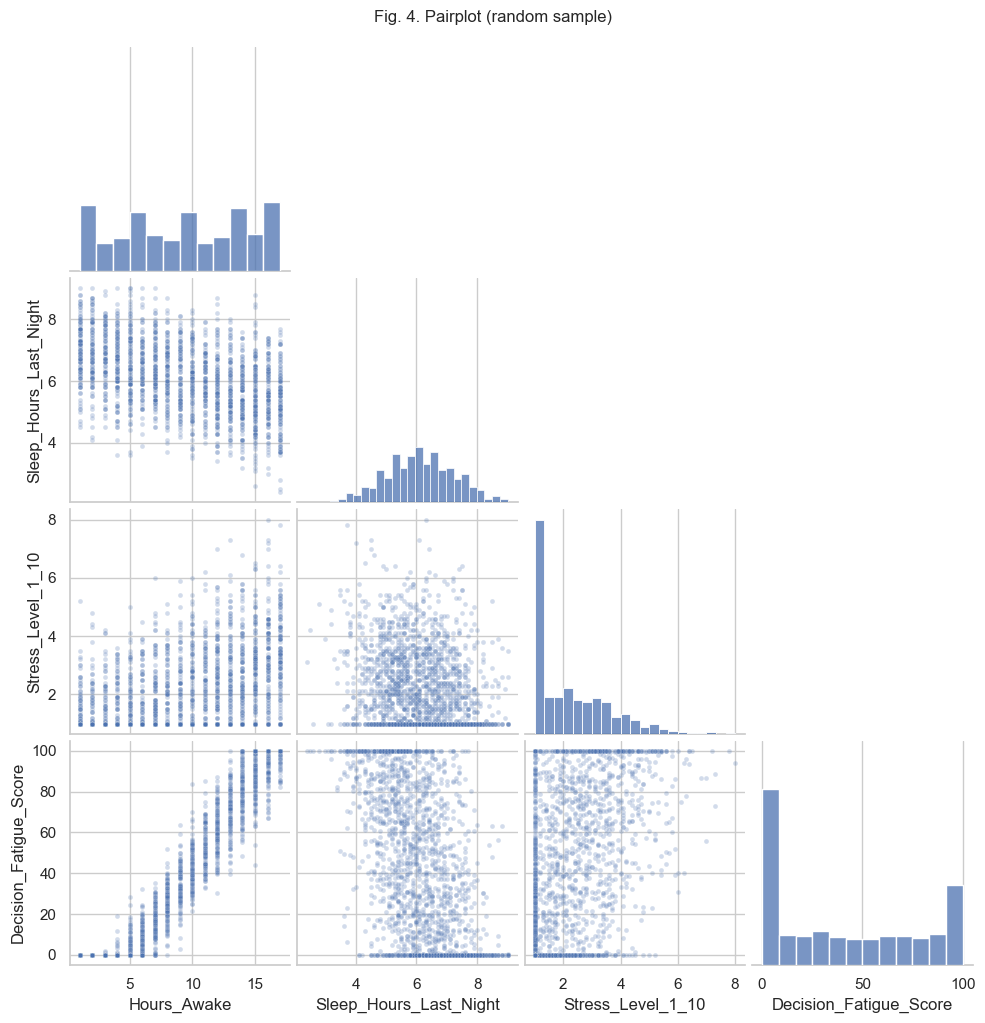

In [7]:
# Fig. 4 — Pairplot (subset for speed)
pair_cols = ["Hours_Awake", "Sleep_Hours_Last_Night", "Stress_Level_1_10", TARGET]
sample = df[pair_cols].sample(min(2000, len(df)), random_state=RANDOM_STATE)
g = sns.pairplot(sample, corner=True, plot_kws={"alpha": 0.25, "s": 12})
g.fig.suptitle("Fig. 4. Pairplot (random sample)", y=1.02)
plt.show()


## 4. Methodology

**Algorithms compared**

| Model | Role |
|-------|------|
| Linear Regression | OLS baseline |
| Ridge (L2) | Regularized linear (`alpha=1`) |
| Random Forest | Nonlinear ensemble |
| Gradient Boosting | Boosted trees |

Each model uses the **same** preprocessing pipeline (scaling + one-hot). Ridge minimizes $\|y - X\beta\|_2^2 + \alpha\|\beta\|_2^2$; tree methods minimize squared error via recursive splits (see scikit-learn docs).

**Evaluation:** identical train/test split for all models; 5-fold CV on training data for stability (Table III).


In [9]:
def make_pipeline(reg):
    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ]
    )
    return Pipeline([("prep", preprocessor), ("reg", reg)])


models = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Ridge (alpha=1)": make_pipeline(Ridge(alpha=1.0)),
    "Random Forest": make_pipeline(
        RandomForestRegressor(
            n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
        )
    ),
    "Gradient Boosting": make_pipeline(
        GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
        )
    ),
}

X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")


Train: 19999  Test: 5000


In [10]:
# Fit all models — Table II
rows = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    r2 = r2_score(y_test, pred)
    rows.append({"Algorithm": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    fitted[name] = (pipe, pred)

results_df = pd.DataFrame(rows).sort_values("RMSE")
print("Table II. Test-set comparison (20% hold-out).")
display(results_df)

best_name = results_df.iloc[0]["Algorithm"]
best_pipe, best_pred = fitted[best_name]
print("Best by RMSE:", best_name)


Table II. Test-set comparison (20% hold-out).


,Algorithm,MAE,RMSE,R2
2,Random Forest,0.902423,1.454588,0.998427
3,Gradient Boosting,1.267385,1.740465,0.997747
1,Ridge (alpha=1),6.111687,7.406811,0.959206
0,Linear Regression,6.111561,7.406870,0.959205


Best by RMSE: Random Forest


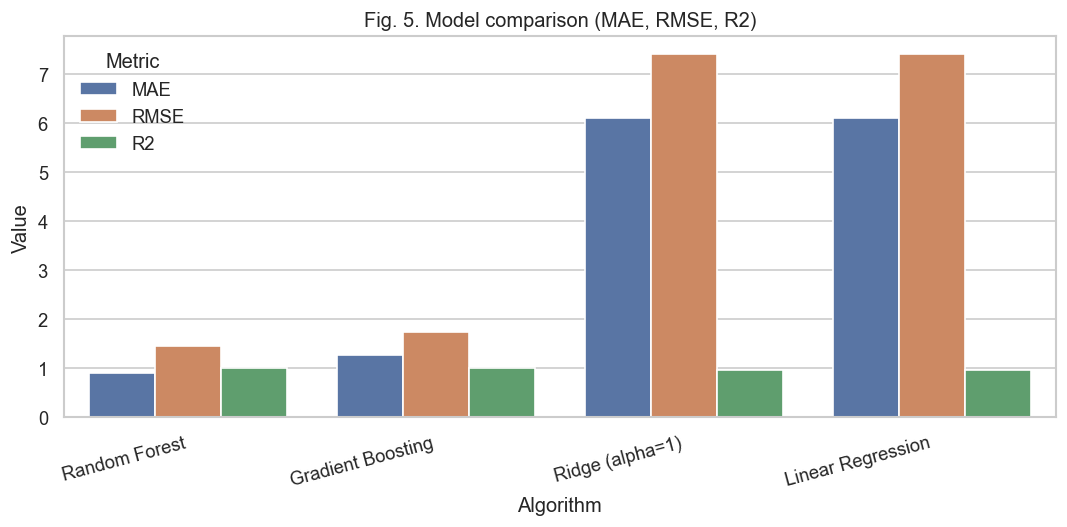

In [11]:
# Fig. 5 — Bar chart of Table II
plot_df = results_df.melt(id_vars="Algorithm", var_name="Metric", value_name="Value")
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=FIG_DPI)
sns.barplot(data=plot_df, x="Algorithm", y="Value", hue="Metric", ax=ax)
ax.set_title("Fig. 5. Model comparison (MAE, RMSE, R2)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.show()


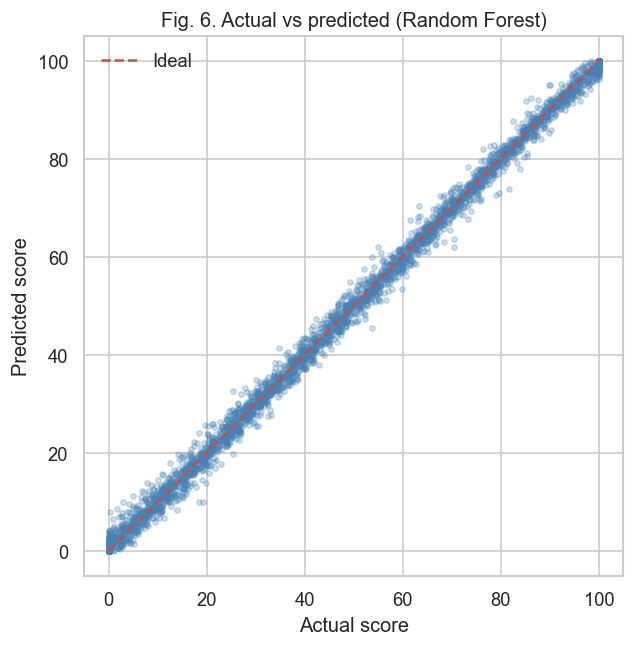

In [12]:
# Fig. 6 — Actual vs predicted (best model)
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=FIG_DPI)
ax.scatter(y_test, best_pred, alpha=0.25, s=10, c="steelblue")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Ideal")
ax.set_xlabel("Actual score")
ax.set_ylabel("Predicted score")
ax.set_title(f"Fig. 6. Actual vs predicted ({best_name})")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


In [ ]:
# Fig. 7 — Residuals
residuals = y_test.values - best_pred
fig, ax = plt.subplots(figsize=(7, 4), dpi=FIG_DPI)
ax.scatter(best_pred, residuals, alpha=0.25, s=10, c="darkgreen")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Predicted score")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Fig. 7. Residual plot")
plt.tight_layout()
plt.show()


In [ ]:
# Fig. 8 — Feature importances (Random Forest)
rf_pipe = fitted["Random Forest"][0]
rf = rf_pipe.named_steps["reg"]
prep = rf_pipe.named_steps["prep"]
prep.fit(X_train, y_train)
feature_names = prep.get_feature_names_out()
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5), dpi=FIG_DPI)
imp.tail(15).plot.barh(ax=ax, color="teal")
ax.set_title("Fig. 8. Random Forest feature importances (top 15)")
plt.tight_layout()
plt.show()


In [ ]:
# Fig. 9 — Ridge coefficients (interpretability)
ridge_pipe = fitted["Ridge (alpha=1)"][0]
ridge = ridge_pipe.named_steps["reg"]
prep_r = ridge_pipe.named_steps["prep"]
prep_r.fit(X_train, y_train)
names = prep_r.get_feature_names_out()
coef = pd.Series(ridge.coef_, index=names).sort_values()
fig, ax = plt.subplots(figsize=(7, 5), dpi=FIG_DPI)
coef.plot.barh(ax=ax, color="slateblue")
ax.set_title("Fig. 9. Ridge regression coefficients (scaled features)")
plt.tight_layout()
plt.show()


In [ ]:
# Table III — 5-fold cross-validation on training data
cv_rows = []
for name, pipe in models.items():
    p = clone(pipe)
    r2_cv = cross_val_score(p, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    p = clone(pipe)
    mae_cv = -cross_val_score(
        p, X_train, y_train, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    cv_rows.append(
        {
            "Algorithm": name,
            "CV R2 mean": r2_cv.mean(),
            "CV R2 std": r2_cv.std(),
            "CV MAE mean": mae_cv.mean(),
            "CV MAE std": mae_cv.std(),
        }
    )
cv_df = pd.DataFrame(cv_rows)
print("Table III. 5-fold cross-validation (training split only).")
display(cv_df)


## 5. Discussion

- **Primary results:** Table II (hold-out test). CV (Table III) checks stability; large gaps between CV and test may indicate distribution shift or noise.
- **Diagnostics:** Fig. 6–7 show calibration and residual spread; ideal residuals are centered at 0 with no strong funnel shape.
- **Interpretability:** Fig. 8 (tree) highlights nonlinear importance; Fig. 9 (Ridge) gives signed linear effects after scaling.
- **Limitations:** Synthetic dataset; external validation required for real deployment.

## 6. Conclusion

This notebook produces **tables and figures** aligned with comparative ML reports: EDA, model comparison, prediction diagnostics, and interpretability plots. **Export figures** at high resolution (e.g. `plt.savefig(..., dpi=300)`) for your PDF.

### Suggested references (edit for your bibliography)
1. Pedregosa et al., scikit-learn.  
2. Russell & Norvig, *Artificial Intelligence: A Modern Approach*.  
3. Dataset source / author documentation.
